# 05 Answer Quality (end-to-end, per use case)

Purpose: end-to-end answer quality — faithfulness / relevance / coherence via
the LLM judge — per use case (question type), from the LLM-judged collection
(`evaluation/notebooks/data/gate_collection.jsonl`). It also relates quality to
gate outcomes (accepted/rejected, confidence, escalation). Fully offline — no
LLM calls; run cells top to bottom.

## 1. Setup

Loads the judged collection and builds a per-question DataFrame. `quality` is
null for rejected questions (no quality judge ran); `judged_correctness` comes
from the final gate entry (null when a question has no gate decision).

In [1]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.notebooks.common import setup

setup()

import matplotlib.pyplot as plt
import pandas as pd

COLLECTION = PROJECT_ROOT / "evaluation" / "notebooks" / "data" / "gate_collection.jsonl"
rows = [json.loads(l) for l in open(COLLECTION) if l.strip()]


def final_correctness(r):
    if not r["gates"]:
        return None
    return r["gates"][-1]["judged_correctness"]


df = pd.DataFrame(
    [
        {
            "question": r["question"],
            "type": r["type"],
            "accepted": r["accepted"],
            "source": r["source"],
            "escalated": r["escalated"],
            "final_confidence": r["final_confidence"],
            "final_relevance": r["final_relevance"],
            "faithfulness": (r["quality"] or {}).get("faithfulness"),
            "relevance": (r["quality"] or {}).get("relevance"),
            "coherence": (r["quality"] or {}).get("coherence"),
            "judged_correctness": final_correctness(r),
        }
        for r in rows
    ]
)

print(f"questions: {len(df)} | accepted: {df['accepted'].sum()} | rejected: {(~df['accepted']).sum()}")
print("per-type distribution:")
print(df["type"].value_counts().sort_index().to_string())

questions: 60 | accepted: 37 | rejected: 23
per-type distribution:
type
ability      13
evolution     8
other        10
stats        18
type         11


## 2. Overall quality

Mean faithfulness / relevance / coherence over the accepted questions, plus
score distributions. Rejected questions have no quality scores (the quality
judge only ran on accepted answers).

overall quality (accepted questions):
faithfulness    4.486
relevance       4.865
coherence       4.973


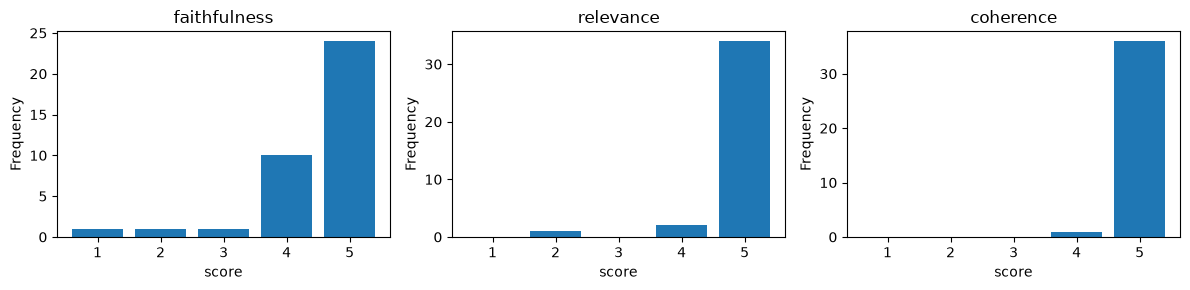

In [2]:
accepted = df[df["accepted"]]
overall = accepted[["faithfulness", "relevance", "coherence"]].mean().round(3)
print("overall quality (accepted questions):")
print(overall.to_string())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, ["faithfulness", "relevance", "coherence"]):
    accepted[col].plot.hist(ax=ax, bins=range(1, 7), align="left", rwidth=0.8)
    ax.set_title(col)
    ax.set_xlabel("score")
plt.tight_layout()
plt.show()

## 3. Per-type quality

Group by question type: n, acceptance rate, mean quality, mean judged
correctness of the final gate answer. Types with small n should be interpreted
with care. This sample contains no `capture` or `habitat` questions.

per-type quality:
            n  acceptance  faithfulness  relevance  coherence  judged_correctness
type                                                                             
ability    13       0.308         4.500      5.000      5.000               4.462
evolution   8       0.875         5.000      5.000      5.000               5.000
other      10       0.700         4.571      5.000      5.000               4.900
stats      18       0.444         4.125      4.500      4.875               4.294
type       11       1.000         4.364      4.909      5.000               4.818


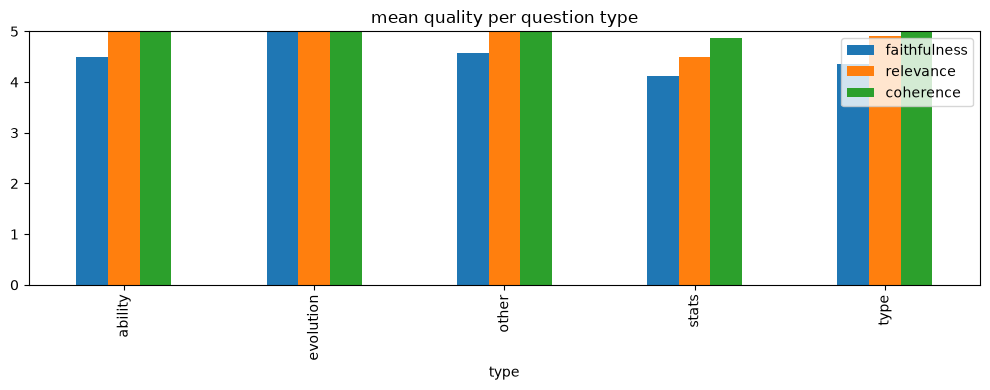

note: quality means cover only accepted questions (rejected have no quality); small-n types are noisy


In [3]:
per_type = df.groupby("type").agg(
    n=("question", "count"),
    acceptance=("accepted", "mean"),
    faithfulness=("faithfulness", "mean"),
    relevance=("relevance", "mean"),
    coherence=("coherence", "mean"),
    judged_correctness=("judged_correctness", "mean"),
).round(3)
print("per-type quality:")
print(per_type.to_string())

per_type[["faithfulness", "relevance", "coherence"]].plot(kind="bar", figsize=(10, 4))
plt.title("mean quality per question type")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()
print("note: quality means cover only accepted questions (rejected have no quality); small-n types are noisy")

## 4. Quality vs gate outcome

Rejected questions have no quality scores, so the accepted-vs-rejected
comparison uses the judged correctness of the final gate answer instead. Then
correlate the gate's `final_confidence` with the quality scores (accepted
questions only): does the grounding gate's confidence track judged quality?

judged correctness of final gate answer by outcome:
          count   mean
accepted              
False        22  4.409
True         37  4.757

correlation of final_confidence with quality (accepted):
                  final_confidence  faithfulness  relevance  coherence
final_confidence             1.000        -0.140      0.112      0.206
faithfulness                -0.140         1.000      0.831      0.654
relevance                    0.112         0.831      1.000      0.904
coherence                    0.206         0.654      0.904      1.000


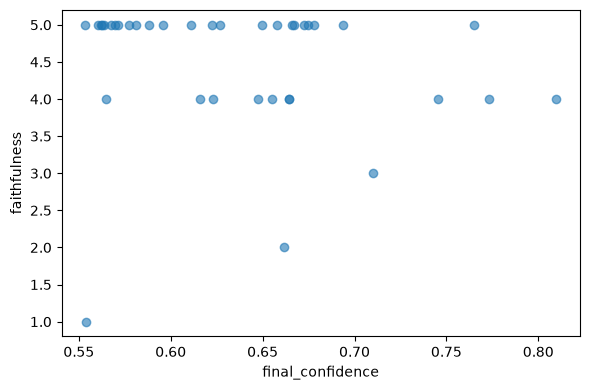

In [4]:
by_outcome = df.groupby("accepted")["judged_correctness"].agg(["count", "mean"]).round(3)
print("judged correctness of final gate answer by outcome:")
print(by_outcome.to_string())

corr = accepted[["final_confidence", "faithfulness", "relevance", "coherence"]].corr().round(3)
print("\ncorrelation of final_confidence with quality (accepted):")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(accepted["final_confidence"], accepted["faithfulness"], alpha=0.6)
ax.set_xlabel("final_confidence")
ax.set_ylabel("faithfulness")
plt.tight_layout()
plt.show()

## 5. Escalation effect

For accepted questions, compare quality between escalated and non-escalated
runs. Escalation fires when the first answer fails the grounding gate; does it
rescue quality or just add latency?

In [5]:
esc = accepted.groupby("escalated")[["faithfulness", "relevance", "coherence"]].agg(
    ["count", "mean"]
).round(3)
print("quality by escalation (accepted questions):")
print(esc.to_string())

quality by escalation (accepted questions):
          faithfulness        relevance        coherence       
                 count   mean     count   mean     count   mean
escalated                                                      
False               28  4.500        28  4.857        28  4.964
True                 9  4.444         9  4.889         9  5.000


## 6. Summary

- **Overall quality is high**: mean faithfulness 4.49, relevance 4.87,
  coherence 4.97 over the 37 accepted questions — accepted answers are well
  grounded, on-topic, and clear.
- **Best types**: `evolution` (faithfulness 5.00, 87.5% acceptance) and
  `other` (4.57) answer cleanly; `type` has perfect acceptance (11/11) with
  faithfulness 4.36. **Worst type**: `stats` — lowest acceptance (44.4%) and
  lowest faithfulness (4.13) and judged correctness (4.29), so stat questions
  are the main quality/grounding bottleneck.
- **Confidence does not track quality**: `final_confidence` correlates
  weakly with faithfulness (-0.14), relevance (0.11), coherence (0.21) — the
  grounding gate's score is not a reliable proxy for judged answer quality.
- **Escalation neither rescues nor hurts quality**: escalated accepted answers
  score essentially the same as non-escalated (faithfulness 4.44 vs 4.50,
  relevance 4.89 vs 4.86, coherence 5.00 vs 4.96) — escalation adds a retry
  without improving the accepted answer.
- **For the agent flow**: `stats` questions need better retrieval/grounding
  (they reject most and score lowest when accepted); the gate's confidence
  should not be read as a quality signal; escalation is a latency cost, not a
  quality fix — improving first-pass grounding (e.g. line-level scoring) is
  the lever, not more retries.